# Storage, Speed, and Transactions

Alex Ronczewski  
2026-07-27

## Outline

### Prerequisites

-   Notebook 5 of this stream: the designed schema.

### Learning Outcomes

By the end of this notebook you will be able to:

1.  Control a **transaction** with `BEGIN`, `COMMIT` and `ROLLBACK`, and
    undo a mistake.
2.  Explain **ACID**, and demonstrate atomicity, isolation and
    durability with a crash we cause on purpose.
3.  Make a slow query fast with an **index**, prove what changed with
    **EXPLAIN QUERY PLAN**, and state what the speed costs.
4.  Explain **row** and **column** storage, and predict which type of
    workloads each one wins.
5.  Justify **Parquet** over CSV for data you keep.

## 1. Where we are in the stream

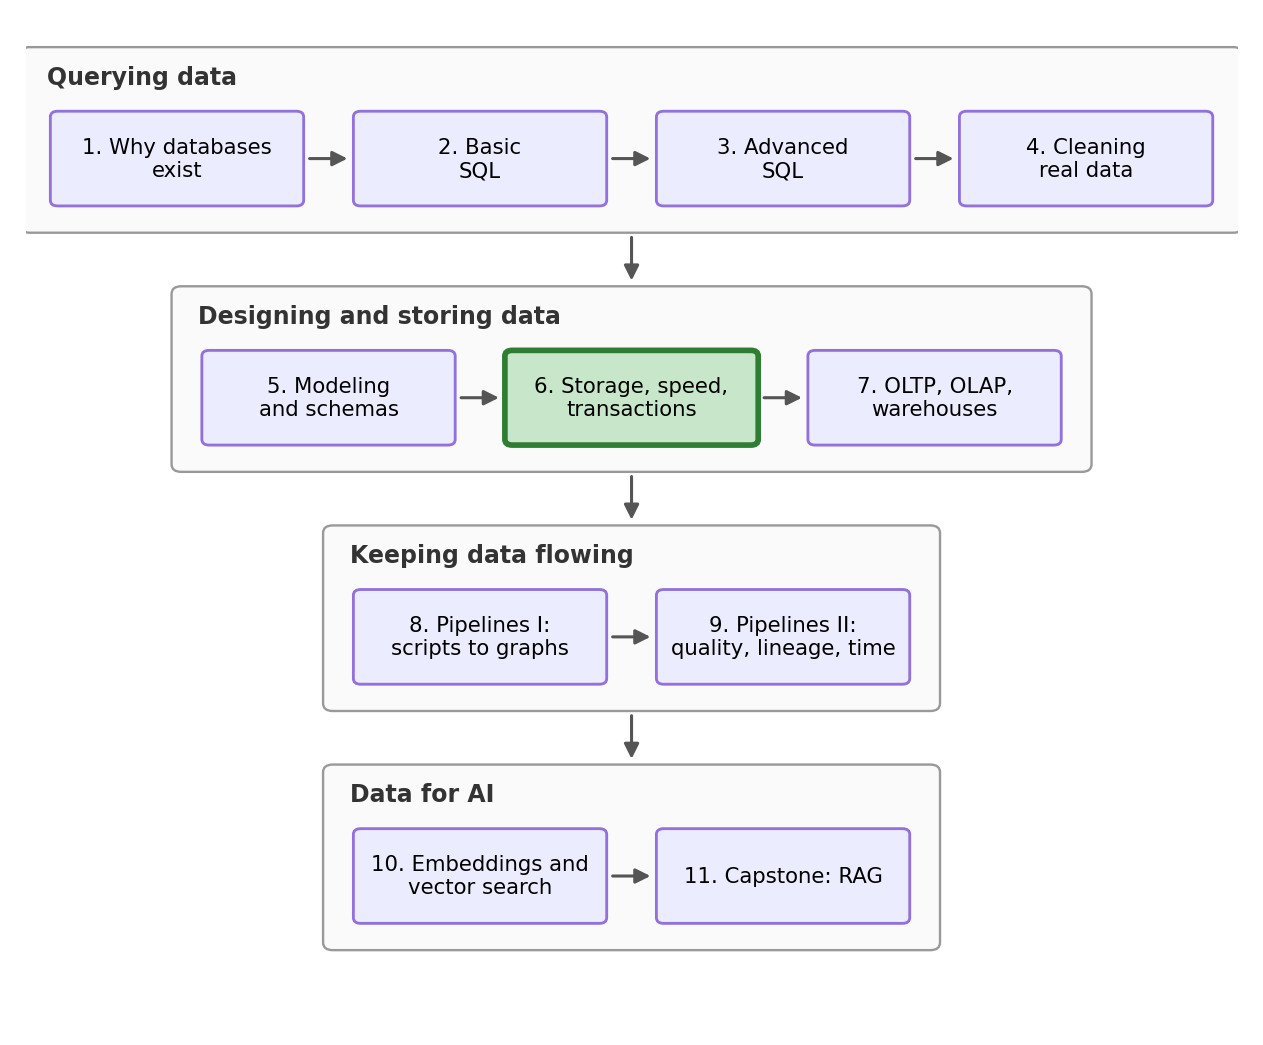

Notebook 5’s design was accepted, and the survey office is building the
wave 2 intake software with it. The schema tells us what a valid record
is. We also received a new email from the survey office for this
notebook’s task.

> **The launch review, from the survey office.** “Three questions before
> we sign off. One: interviewers’ laptops have died mid-interview in the
> past, so tell us what a crash does to the data. Two: looking up a
> respondent’s history has to stay instant once this thing holds years
> of responses. Three: the research side wants analytics on the archive
> without waiting all day, and wants to know what file format we keep
> the history in.”

Three questions, and in this notebook we answer each with an experiment
(fun)! Along the way we meet the mechanism beneath everything this
stream has done so far: how a database writes without losing data, how
it finds one row without reading them all, and how the same data can sit
on disk in shapes whose speed differs a hundredfold.

## 2. A quarter of a million rows

Every experiment today needs something the 1,000-row survey cannot give
us: enough data for speed to matter. So we simulate the amount: two
years of wave 2 operation, 250,000 interview responses, 250 times the
survey we have been using so far. The grain is one row per response, and
the same person can appear many times, once per interview they gave.

In [1]:
import os
import time
import sqlite3
import duckdb
import numpy as np
import pandas as pd

`numpy`’s random generator does the manufacturing. `default_rng(42)`
builds a generator with a fixed seed, so every run of this notebook
produces the identical dataset.

In [2]:
rng = np.random.default_rng(42)
n = 250_000

provinces = ["Ontario", "Quebec", "British Columbia", "Alberta", "Manitoba", "Saskatchewan"]
weights = [0.42, 0.23, 0.15, 0.13, 0.04, 0.03]
industries = ["Construction", "Education", "Finance", "Health care", "Hospitality",
              "Manufacturing", "Public administration", "Retail", "Technology"]

big = pd.DataFrame({
    "response_id": np.arange(1, n + 1),
    "respondent_id": rng.integers(1, 60_001, n),
    "interview_date": pd.Timestamp("2026-09-01") + pd.to_timedelta(rng.integers(0, 730, n), unit="D"),
    "province": rng.choice(provinces, n, p=weights),
    "industry": rng.choice(industries, n),
    "age": rng.integers(19, 66, n),
    "weekly_hours": rng.normal(37, 6, n).clip(5, 80).round(1),
    "hourly_wage": rng.lognormal(3.6, 0.33, n).clip(17.40, None).round(2),
})
big.head()

Note: Saskatchewan made the province list this time, since we are past
those issues, so we won’t run into any new NULL-related problems.

Into SQLite it goes, through the same `to_sql` as always, in a fresh
database file. One adjustment first so this all works: SQLite keeps
dates as ISO text (Notebook 4’s `2025-01-14` format), so we convert the
dates to text with `.dt.strftime`, which is the `pandas` equivalent of
the SQL `strftime` from Notebook 4. And to be clear about what we are
building: this is a staging-style scratch table with no keys and no
constraints, because today we are measuring the engine, not working with
the data. Notebook 5 would be really upset with us right now, but
luckily it’s not here to see. If this was a real database, we would also
add all of Notebook 5’s content.

In [3]:
conn = sqlite3.connect("datasets/wage_responses.db")

for_sqlite = big.copy()
for_sqlite["interview_date"] = for_sqlite["interview_date"].dt.strftime("%Y-%m-%d")
for_sqlite.to_sql("responses", conn, index=False, if_exists="replace")

250000

250 thousand rows written. One small new tool: `os.path.getsize` asks
the operating system how big a file is, in bytes, so we can watch the
database grow throughout the notebook.

In [4]:
conn.execute("VACUUM")

print(f"{os.path.getsize('datasets/wage_responses.db') / 1e6:.0f} MB on disk")
pd.read_sql("SELECT COUNT(*) AS responses, COUNT(DISTINCT respondent_id) AS respondents FROM responses", conn)

17 MB on disk

About 17 MB, holding 250,000 responses from 59,037 distinct respondents.
Time to break things.

## 3. The undo button

Question one from the office is about crashes, and the machinery that
answers it is **transactions**: a group of statements the database
promises to treat as one unit. It either incorporates all of them or
none of them. `BEGIN` opens the transaction, `COMMIT` makes everything
since `BEGIN` permanent, and `ROLLBACK` throws everything since `BEGIN`
away. If you are familiar with version control like Git, this is the
database equivalent.

For this example we will do something new, our connections to the
database will be controlled by hand (this is necessary to prematurely
end the connection). On this connection nothing is committed unless we
say so inside SQL itself. This is necessary for the experiment, but you
don’t have to focus too much on the mechanism itself.

In [5]:
txn = sqlite3.connect("datasets/wage_responses.db", isolation_level=None)

Now, the demonstration. Gallery #3 in Notebook 3 had a colleague running
an `UPDATE` with no `WHERE` and overwriting every row of a practice
table, and our advice was to rehearse on a copy. Transactions are the
professional version of that advice. Watch us make the exact same
catastrophic mistake, on the real table, on purpose. First, the truth we
are about to destroy:

In [6]:
pd.read_sql("SELECT ROUND(AVG(weekly_hours), 2) AS avg_hours FROM responses", txn)

An average of 37.01 hours a week. Open a transaction and destroy it:

In [7]:
txn.execute("BEGIN")
txn.execute("UPDATE responses SET weekly_hours = 40")

pd.read_sql("SELECT ROUND(AVG(weekly_hours), 2) AS avg_hours FROM responses", txn)

Every one of 250,000 values now reads exactly 40. In Notebook 3 this was
the disaster. Luckily here this is not permanent, because the
transaction is still open, and nothing has been committed:

In [8]:
txn.execute("ROLLBACK")

pd.read_sql("SELECT ROUND(AVG(weekly_hours), 2) AS avg_hours FROM responses", txn)

We are back to 37.01 again. 250,000 overwrites, undone by one command.
That is what a transaction offers: between `BEGIN` and the moment you
commit, the database lets you see your changes, check them, and revert
them.

## 4. Crashing on purpose

A `ROLLBACK` is just you changing your mind. The office’s question is
more extreme: what if the machine dies before anyone gets to decide? To
find out, we pretend to be the dying laptop ourselves. A third
connection opens a transaction and loads a batch of a thousand arriving
interviews, which we fake by copying the first thousand responses under
new ids:

In [9]:
crash = sqlite3.connect("datasets/wage_responses.db", isolation_level=None)
crash.execute("BEGIN")
crash.execute("""INSERT INTO responses
                 SELECT response_id + 1000000, respondent_id, interview_date, province,
                        industry, age, weekly_hours, hourly_wage
                 FROM responses
                 WHERE response_id <= 1000""")

pd.read_sql("SELECT COUNT(*) AS what_the_writer_sees FROM responses", crash)

The writing connection counts 251,000 rows. Now ask the same question
through our other connection, at the same moment:

In [10]:
pd.read_sql("SELECT COUNT(*) AS what_everyone_else_sees FROM responses", conn)

250,000. The writer sees its work in progress; everyone else sees the
last committed state, and will keep seeing it until the writer commits.
Uncommitted work is invisible to the outside world, which is exactly
what we want: if we are loading new data while a co-worker runs an
analysis, it would be bad if their answers kept changing every few
seconds.

> **Predict first.** The interviewer’s laptop dies right now,
> transaction open, 1,000 rows written but not committed. After the
> machine restarts, how many rows does the table hold?

In [11]:
crash.close()

pd.read_sql("SELECT COUNT(*) AS after_the_crash FROM responses", conn)

250,000. The uncommitted batch vanishes, as if it never started, and
that is exactly what we want: not 251,000, and not some value in
between. Closing the connection with the transaction open plays the part
of the crash; a real power cut can leave the database file itself
half-written, but SQLite writes the journal to disk in full before
touching the database, so the journal survives intact, and SQLite uses
it to roll the database back to the last committed state the next time
anything connects. Either way the rule holds, and it is the same rule
that refused our 1,000-row load in Notebook 5: a transaction finishes
entirely or leaves no trace.

For completeness, here is the run where the laptop survives long enough
to commit:

In [12]:
survivor = sqlite3.connect("datasets/wage_responses.db", isolation_level=None)
survivor.execute("BEGIN")
survivor.execute("""INSERT INTO responses
                    SELECT response_id + 1000000, respondent_id, interview_date, province,
                           industry, age, weekly_hours, hourly_wage
                    FROM responses
                    WHERE response_id <= 1000""")
survivor.execute("COMMIT")
survivor.close()

pd.read_sql("SELECT COUNT(*) AS after_a_commit FROM responses", conn)

251,000. Once `COMMIT` returns, the change has been forced onto the disk
itself, and a crash one millisecond later cannot revert it. Our load
test does not need the extra thousand rows, so we remove them again, on
the manual connection, where every statement commits itself:

In [13]:
txn.execute("DELETE FROM responses WHERE response_id > 1000000")

pd.read_sql("SELECT COUNT(*) AS back_to_normal FROM responses", conn)

> **ACID**
>
> What we just demonstrated has a name that appears in every database
> book. A transaction is **ACID**:
>
> **Atomic**: all or nothing, the crashed batch left zero rows, never
> 400. **Consistent**: every rule of the schema holds before and after,
> never half-enforced in between; Notebook 5’s constraints rely on this.
> **Isolated**: connections do not see each other’s unfinished work, our
> second connection counted 250,000 while the first counted 251,000.
> **Durable**: committed means written to disk, and a crash after commit
> loses nothing.
>
> Notebook 1 promised that a database will “never lose a row, never let
> two edits collide.” This is the machinery behind that promise.

## 5. What a commit costs

Durability is not free. Committing means forcing bytes onto the physical
disk and waiting for the disk to confirm, which is one of the slowest
core operations a computer can run. That has a consequence for how you
load data.

> **Wrong-query gallery #5**
>
> A colleague wrote the nightly loader for the intake system. It saves
> each response the moment it is processed, and it is taking forever. We
> can have a look, timing it with a new tool: `time.perf_counter()`
> reads a high-precision stopwatch, so reading it before and after a job
> and subtracting gives the job’s duration. This pattern appears in
> every timing in the rest of the notebook.
>
> ``` python
> start = time.perf_counter()
>
> for i in range(500):
>     txn.execute("INSERT INTO responses VALUES (?, ?, '2027-01-15', 'Ontario', 'Technology', 30, 40.0, 35.00)",
>                 (2_000_000 + i, 12345))
>
> print(f"500 saves, one commit each: {time.perf_counter() - start:.2f} seconds")
> ```
>
>     500 saves, one commit each: 1.08 seconds
>
> Around a second for five hundred rows, on this machine. The full
> nightly batch is 50,000 rows. Why is it so slow? What can we change to
> fix this?
>
> <details>
>
> <summary>
>
> Show / hide answer
>
> </summary>
>
> The `txn` connection commits after every statement, so this loop is
> 500 transactions, and each commit waits for the disk. The added rows
> themselves are not the cost; the commits themselves are. The fix is to
> make the batch what it already is conceptually, one unit of work:
>
> ``` python
> start = time.perf_counter()
>
> txn.execute("BEGIN")
> for i in range(500):
>     txn.execute("INSERT INTO responses VALUES (?, ?, '2027-01-15', 'Ontario', 'Technology', 30, 40.0, 35.00)",
>                 (3_000_000 + i, 12345))
> txn.execute("COMMIT")
>
> print(f"500 saves, one commit total: {time.perf_counter() - start:.3f} seconds")
>
> txn.execute("DELETE FROM responses WHERE response_id >= 2000000")   # remove both test batches again
> ```
>
>     500 saves, one commit total: 0.004 seconds
>
>     <sqlite3.Cursor at 0x239056580c0>
>
> Same 500 rows, a few milliseconds: several hundred times faster here,
> and your exact numbers will differ based on your machine, but the
> ratio is the core result. One caution before you batch everything in
> sight: the intake software itself should keep committing per response,
> because each response must survive the very next crash. Batching is
> for bulk jobs, where losing an uncommitted half-batch costs a re-run
> and nothing more.
>
> </details>

## 6. Finding one row in 250,000

Question two from the survey office: respondent lookup has to stay
instant. Here is the lookup, which we time like before. Respondent 54001
is the busiest person in our simulation, with 14 interviews across the
two years:

In [16]:
start = time.perf_counter()
one_person = pd.read_sql("SELECT * FROM responses WHERE respondent_id = 54001", conn)
print(f"{1000 * (time.perf_counter() - start):.1f} ms to find {len(one_person)} rows")

30.9 ms to find 14 rows

Tens of milliseconds for 14 rows. That sounds fast until you scale it:
it means the database examined all 250,000 rows to find them, and at 25
million rows the same lookup takes a hundred times longer. We do not
have to guess that it examined everything, because SQLite will describe
its own strategy. Run `EXPLAIN QUERY PLAN` before any query and instead
of running it, the database reports how it would. The report comes back
as a small table, and `.iloc[0]` pulls the first row’s value out of a
dataframe column so we can read the strategy in full:

In [17]:
plan = pd.read_sql("EXPLAIN QUERY PLAN SELECT * FROM responses WHERE respondent_id = 54001", conn)
print(plan["detail"].iloc[0])

SCAN responses

`SCAN responses`: read the table top to bottom, checking every row. This
is the simplest method, and not a very efficient one. A phone book does
not make you read every entry to find one person. It keeps the entries
sorted, so you can open near the middle, see which half your name is in,
and repeat. Each step halves the search, and halving is extraordinarily
effective: 250,000 rows collapse in about 18 steps, and a billion rows
in about 30.

An **index** is that sorted phone book, built as a side structure on a
column you choose, with each entry pointing back to its row in the
table. The tree-shaped form databases use is called a **B-tree**, and it
is the default nearly everywhere because staying sorted buys ranges too:
“everyone between here and here” is one walk along the leaves. (The main
alternative, a hash table like Python’s dictionaries, answers exact
matches very well, but it can’t do ranges.) We will not go too deep into
B-trees here as they belong to the computer science world of data
structures and algorithms, but if you are curious and want to read more:
[Introduction to
B-Trees](https://www.geeksforgeeks.org/dsa/introduction-of-b-tree-2/).

Building one is a single statement naming the table and column:

In [18]:
start = time.perf_counter()
conn.execute("CREATE INDEX idx_responses_respondent ON responses(respondent_id)")
print(f"index built in {time.perf_counter() - start:.1f} seconds")

index built in 0.2 seconds

The same lookup again:

In [19]:
start = time.perf_counter()
one_person = pd.read_sql("SELECT * FROM responses WHERE respondent_id = 54001", conn)
print(f"{1000 * (time.perf_counter() - start):.2f} ms to find {len(one_person)} rows")

1.12 ms to find 14 rows

Around a millisecond, roughly thirty times faster on this machine, and
the gap widens as tables grow, because the scan grows with the table and
the tree walk barely grows at all. The plan confirms the strategy
changed:

In [20]:
plan = pd.read_sql("EXPLAIN QUERY PLAN SELECT * FROM responses WHERE respondent_id = 54001", conn)
print(plan["detail"].iloc[0])

SEARCH responses USING INDEX idx_responses_respondent (respondent_id=?)

`SEARCH` using the index, instead of `SCAN`.

So why not index every column? Because an index is a real data structure
that has to be stored and maintained:

In [21]:
print(f"{os.path.getsize('datasets/wage_responses.db') / 1e6:.0f} MB on disk")

20 MB on disk

About 20 MB now, up from 17: one index on one integer column grew the
database by roughly a sixth. The bigger cost is on writes. Every
`INSERT` now has to place the new row in the table and slot its entry
into the sorted tree, and a second index would mean a third structure to
update. Indexes convert write speed into read speed, so you buy them for
the lookups you actually make, and no more.

## 7. Why analytics reads columns

Question three starts with a complaint. The research side does not look
up individuals; it asks summary questions across everything, like the
regional briefing from Notebook 2, but this time all the `SELECT`s will
be 250 times the size. Here is that question, timed:

In [22]:
question = """SELECT province, COUNT(*) AS responses, ROUND(AVG(hourly_wage), 2) AS avg_wage
              FROM responses
              GROUP BY province
              ORDER BY avg_wage DESC"""

start = time.perf_counter()
by_province = pd.read_sql(question, conn)
print(f"SQLite: {1000 * (time.perf_counter() - start):.0f} ms")
by_province

SQLite: 180 ms

A couple of hundred milliseconds. The number that matters today is the
time. Two hundred milliseconds for one question is fine, until it is a
dashboard running fifty questions on a table a hundred times bigger.

Notice what the query needed: two columns. And notice what SQLite had to
do anyway: read the entire table, because of how it stores rows. SQLite
is a **row store**: each row’s values sit together on disk, which is
perfect for the intake side, since saving one response writes one block,
and fetching respondent 54001 reads a few. A **column store** flips the
layout: all values of one column sit together, so a query touches only
the columns it mentions, and each block compresses beautifully because
similar values are neighbours.

<figure>
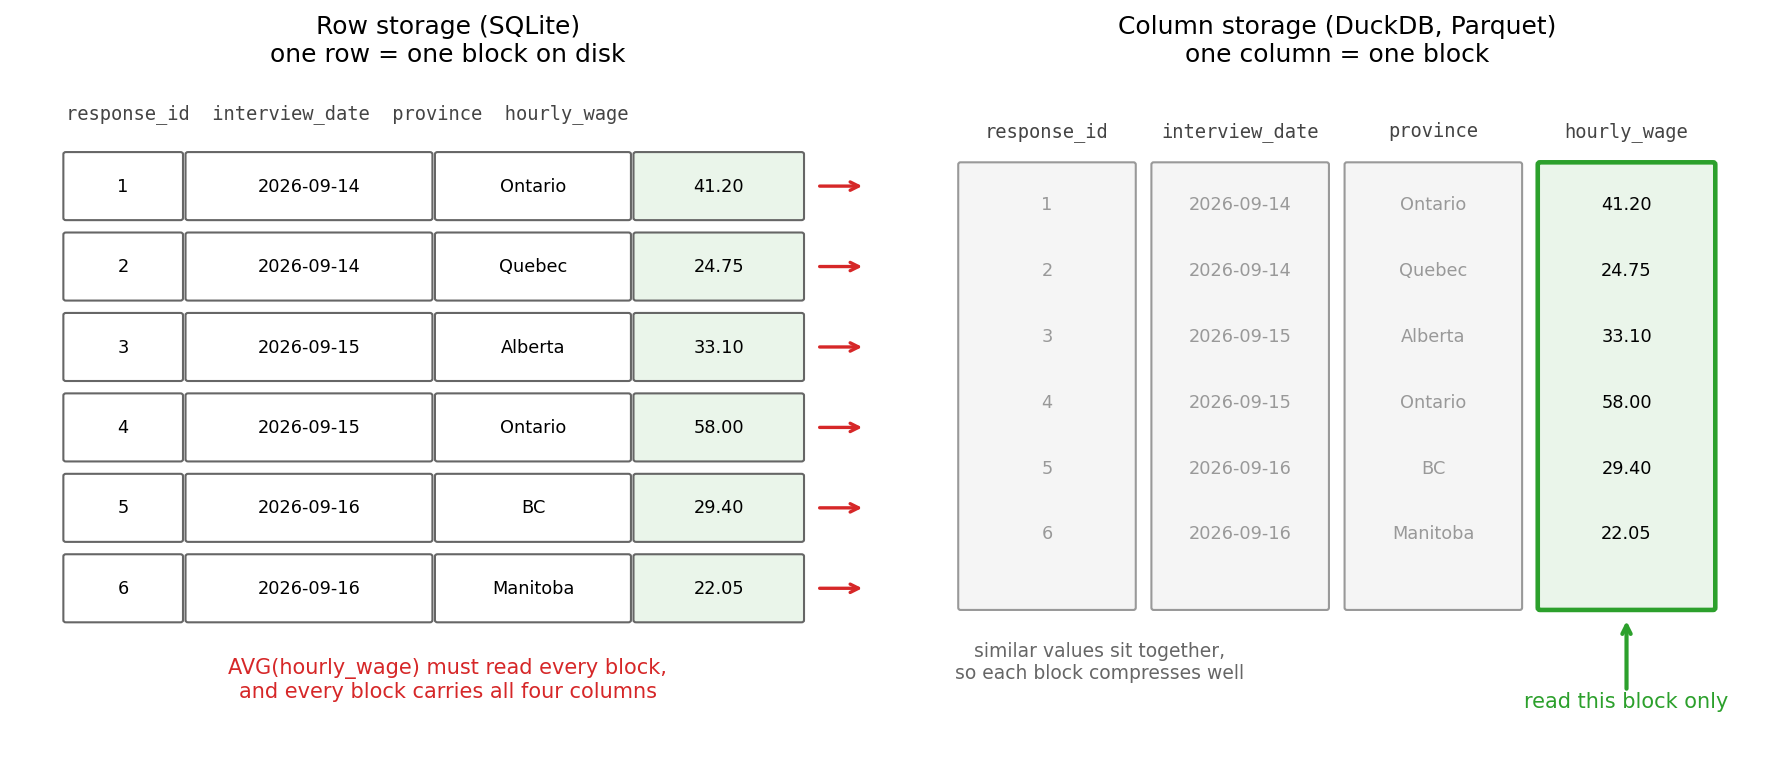
<figcaption aria-hidden="true">The same six responses, stored two ways.
Row storage writes and fetches whole records efficiently, but is worse
whenever a query wants one column of everything. Column storage reads
only what the query names.</figcaption>
</figure>

The column storage we can test this claim on is **DuckDB**: like SQLite
it is free, runs inside the notebook, and keeps its data in a single
file or in memory, and unlike SQLite it stores columns and processes
them in bulk. It has one more trick which is amazing for our use case:
it can see the dataframes in your session and query them by name. We
don’t have to re-run everything. The `.df()` on the end of a DuckDB
command asks for the result as a dataframe, the job `pd.read_sql` has
been doing for SQLite:

In [23]:
duck = duckdb.connect()
duck.execute("CREATE TABLE responses AS SELECT * FROM big")
duck.execute("SELECT COUNT(*) AS loaded FROM responses").df()

Now the identical question:

In [24]:
start = time.perf_counter()
duck_answer = duck.execute(question).df()
print(f"DuckDB: {1000 * (time.perf_counter() - start):.0f} ms")
duck_answer

DuckDB: 6 ms

Identical command on an identical table, and on this machine tens of
times faster, down to single-digit milliseconds. Notebook 1 said SQL is
declarative: you state what you want and the engine decides how. This is
proof of that. We gave the same command to two different engines, and
they chose differently because their storage shapes differ, one reading
every block of every row, the other reading two column strips.

Neither engine is the better one. SQLite wins the intake workload of
many small precious writes, DuckDB wins the analytical workload of few
enormous reads, and the same organization usually needs both at once.
This core tension, and the industry’s solution to it, is the whole of
Notebook 7.

## 8. What format to keep it in

The last question is the archive. The office will keep the raw response
history for years, outside any database, in files. The most obvious
answer is CSV, which is where we started this stream. Let us give the
intuitive answer a fair test:

In [25]:
start = time.perf_counter()
big.to_csv("datasets/wage_responses.csv", index=False)
print(f"CSV: written in {time.perf_counter() - start:.1f} s, "
      f"{os.path.getsize('datasets/wage_responses.csv') / 1e6:.0f} MB")

CSV: written in 0.7 s, 15 MB

> **Predict first.** The same dataframe is about to be written as
> **Parquet**, a format designed for exactly this job. It stores columns
> rather than rows, section 7’s idea carried into the file itself, and
> compresses each column strip. The CSV is about 15 MB. What about the
> Parquet?

In [26]:
start = time.perf_counter()
big.to_parquet("datasets/wage_responses.parquet")
print(f"Parquet: written in {time.perf_counter() - start:.1f} s, "
      f"{os.path.getsize('datasets/wage_responses.parquet') / 1e6:.0f} MB")

Parquet: written in 0.1 s, 3 MB

3 MB, five times smaller, written faster than the CSV. (`to_parquet`
works because the `pyarrow` library is installed; it is the standard
engine for Parquet in Python.) Reading shows the same order:

In [27]:
start = time.perf_counter()
from_csv = pd.read_csv("datasets/wage_responses.csv")
print(f"read the CSV back:     {time.perf_counter() - start:.2f} s")

start = time.perf_counter()
from_parquet = pd.read_parquet("datasets/wage_responses.parquet")
print(f"read the Parquet back: {time.perf_counter() - start:.2f} s")

read the CSV back:     0.17 s
read the Parquet back: 0.06 s

An insignificant gap at this size can balloon at real scale, where a CSV
must be parsed character by character while Parquet’s columns load
nearly ready to use. But speed and size are a far smaller reason to
choose Parquet compared to the next part. Compare what survived the
round trip:

In [28]:
print("interview_date from the CSV:    ", from_csv["interview_date"].dtype)
print("interview_date from the Parquet:", from_parquet["interview_date"].dtype)

interview_date from the CSV:     object
interview_date from the Parquet: datetime64[ns]

The CSV returned our dates as `object`, which is plain text, because a
CSV stores no types at all, and every `read_csv` starts the guessing
game that opened Notebook 4. The Parquet returned `datetime64`, exactly
what we wrote, because a Parquet file carries a schema inside it: every
column’s name and type travel with the data. Notebook 5 taught that
types belong in the schema, and Parquet is that idea for files. An
archive that cannot forget its own types is an archive Notebook 4 never
has to rescue.

One more payoff, DuckDB treats a Parquet file as a table you can query
in place, no loading step at all:

In [29]:
duck.execute("""SELECT province, ROUND(AVG(hourly_wage), 2) AS avg_wage
                FROM 'datasets/wage_responses.parquet'
                GROUP BY province
                ORDER BY avg_wage DESC
                LIMIT 3""").df()

That is a query running against a file sitting in a folder. A pile of
Parquet files sitting in some cheap storage plus an engine that queries
them is what industry calls a data lake, and we will talk about it more
in Notebook 7.

## 9. Conclusion

The launch review gets its three answers, each with an experiment
attached, and we can go home early. A crash mid-write cannot half-save
an interview: transactions are atomic, the batch that died with the
laptop left zero rows, and a second connection stayed isolated from
uncommitted work. Respondent lookup stays instant at scale: an index
took the search from a scan of everything to a tree walk,
`EXPLAIN QUERY PLAN` proved the strategy changed, and the cost was a
sixth more disk and slower writes. And the archive goes to Parquet,
smaller than CSV, faster, and carrying its schema inside, with DuckDB
querying it in place for the research archive.

Underneath all three runs one idea: the shape data takes on disk decides
what is fast, what is safe, and what is possible. The intake side wants
rows, transactions, and an index on respondents. The research side wants
columns and doesn’t care about single rows. One copy of the data cannot
be the best shape for both jobs, and pretending otherwise is where a lot
of slow systems come from. Splitting the two properly is Notebook 7.

> **You can now answer these interview questions**
>
> -   What is a transaction, and what does ACID stand for?
> -   A production query is slow. How do you diagnose it, how do you fix
>     it, and what does the fix cost?
> -   Why do analytical databases store data by column?
> -   Why would you archive data as Parquet instead of CSV?
>
> <details>
>
> <summary>
>
> Show / hide model answers
>
> </summary>
>
> -   A group of statements the database applies as one unit. Atomic:
>     all or nothing. Consistent: every rule holds before and after.
>     Isolated: concurrent connections do not see each other’s
>     unfinished work. Durable: once committed, a crash loses nothing.
> -   Read its plan with `EXPLAIN QUERY PLAN` (or `EXPLAIN` elsewhere);
>     a `SCAN` on a large table with a selective filter wants an index
>     on the filtered column, turning the scan into a `SEARCH`. The cost
>     is disk space and slower writes, since every insert or update must
>     also maintain the index.
> -   Analytical queries touch few columns of many rows. Storing each
>     column together means reading only the columns the query names,
>     and similar neighbouring values compress well, so the engine moves
>     far fewer bytes for the same answer.
> -   Parquet is column-oriented and compressed, several times smaller
>     and faster to read than CSV, and it stores each column’s type
>     inside the file, so nothing about the data has to be guessed on
>     the way back in.
>
> </details>

## Connections

-   **Back to [Notebook 5](notebook_05_designing_data.qmd):** the schema
    said what may be stored; this notebook was how it is stored. The
    all-or-nothing behaviour behind Notebook 5’s refused load now has
    its name and its mechanism, the atomic transaction.
-   **Forward to [Notebook 7](notebook_07_two_kinds_of_databases.qmd):**
    we saw one engine win at writing rows and another at reading
    columns. Next, the architecture built on that split: transactional
    and analytical databases, star schemas, the ETL between them, and
    where warehouses and lakes fit.

### References

-   Haerder, T., & Reuter, A. (1983). *Principles of
    transaction-oriented database recovery.* ACM Computing Surveys,
    15(4), 287-317. The paper that coined ACID.
-   Kleppmann, M. (2017). *Designing Data-Intensive Applications.*
    O’Reilly. Chapter 3 is this notebook in book form: B-trees, column
    storage, and why each exists.
-   Malan, D. (2024). *CS50’s Introduction to Databases with SQL.*
    Harvard University. https://cs50.harvard.edu/sql/ The lecture on
    optimizing covers indexes and transactions.
-   SQLite. *Atomic commit in SQLite.*
    https://www.sqlite.org/atomiccommit.html How the journal file makes
    section 4’s crash survivable.
-   SQLite. *EXPLAIN QUERY PLAN.* https://www.sqlite.org/eqp.html
    Reading SCAN and SEARCH, from the engine’s own documentation.
-   Winand, M. *Use the Index, Luke!* https://use-the-index-luke.com A
    free book on indexes and the queries that use or defeat them.
-   DuckDB. *Why DuckDB.* https://duckdb.org/why_duckdb The design goals
    behind section 7’s benchmark.
-   Apache Software Foundation. *Apache Parquet documentation.*
    https://parquet.apache.org/docs/ The column format carrying section
    8’s schema.

------------------------------------------------------------------------